 # 01 - Exploratory Data Analysis

 **Goal:** Understand the sparsity, long-tail effects, and user behavior in the "Headphones" dataset.



 This notebook produces figures saved to `reports/figures/` for the LaTeX report.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

In [18]:
# Load Data
train = pd.read_parquet('../data/processed/train.parquet')
val = pd.read_parquet('../data/processed/val.parquet')
test = pd.read_parquet('../data/processed/test.parquet')

df = pd.concat([train, val, test])
print(f"Total Interactions: {len(df)}")
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Total Interactions: 2695
Train: 1888, Val: 407, Test: 400


 ## 1. Dataset Statistics

In [19]:
n_users = df['reviewerID'].nunique()
n_items = df['asin'].nunique()
n_interactions = len(df)
matrix_size = n_users * n_items
sparsity = 1 - (n_interactions / matrix_size)

print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)
print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Interactions: {n_interactions}")
print(f"Matrix Size: {matrix_size:,}")
print(f"Sparsity: {sparsity:.6f} ({sparsity*100:.4f}%)")
print(f"Density: {(1-sparsity)*100:.4f}%")
print("=" * 50)

# Save stats to file
with open(f'{FIGURES_DIR}/dataset_stats.txt', 'w') as f:
    f.write(f"Users: {n_users}\n")
    f.write(f"Items: {n_items}\n")
    f.write(f"Interactions: {n_interactions}\n")
    f.write(f"Sparsity: {sparsity*100:.2f}%\n")


DATASET STATISTICS
Users: 368
Items: 282
Interactions: 2695
Matrix Size: 103,776
Sparsity: 0.974031 (97.4031%)
Density: 2.5969%


 ## 2. Long-Tail Distribution (Items)



 The "long-tail" effect is characteristic of recommender systems: a few items receive most interactions.

Saved: reports/figures/fig_longtail.png


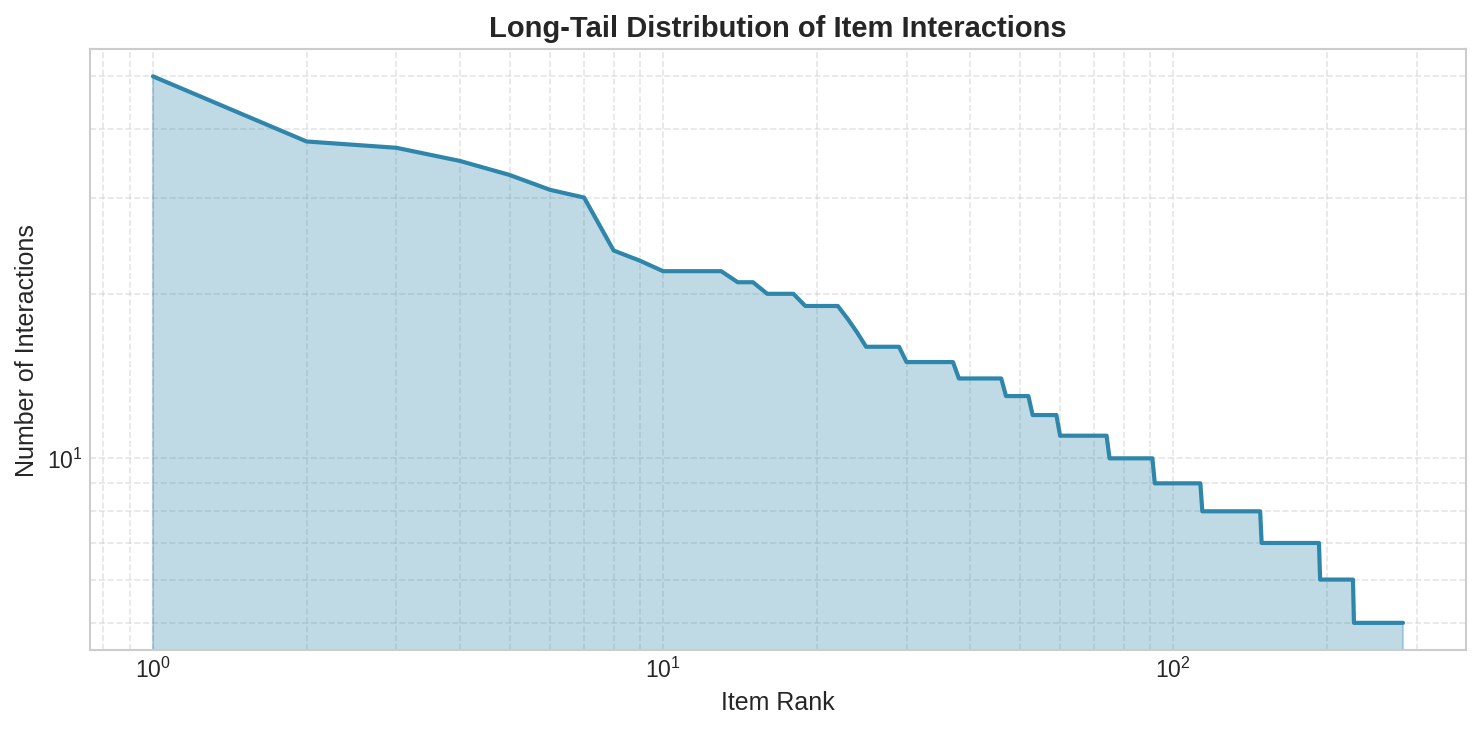

In [20]:
item_counts = df['asin'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(item_counts)+1), item_counts.values, color='#2E86AB', linewidth=2)
ax.set_title('Long-Tail Distribution of Item Interactions', fontsize=14, fontweight='bold')
ax.set_xlabel('Item Rank', fontsize=12)
ax.set_ylabel('Number of Interactions', fontsize=12)
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which="both", ls="--", alpha=0.5)
ax.fill_between(range(1, len(item_counts)+1), item_counts.values, alpha=0.3, color='#2E86AB')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_longtail.png', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_longtail.pdf', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_longtail.png")
plt.show()

 ## 3. User Activity Distribution

Saved: reports/figures/fig_user_activity.png


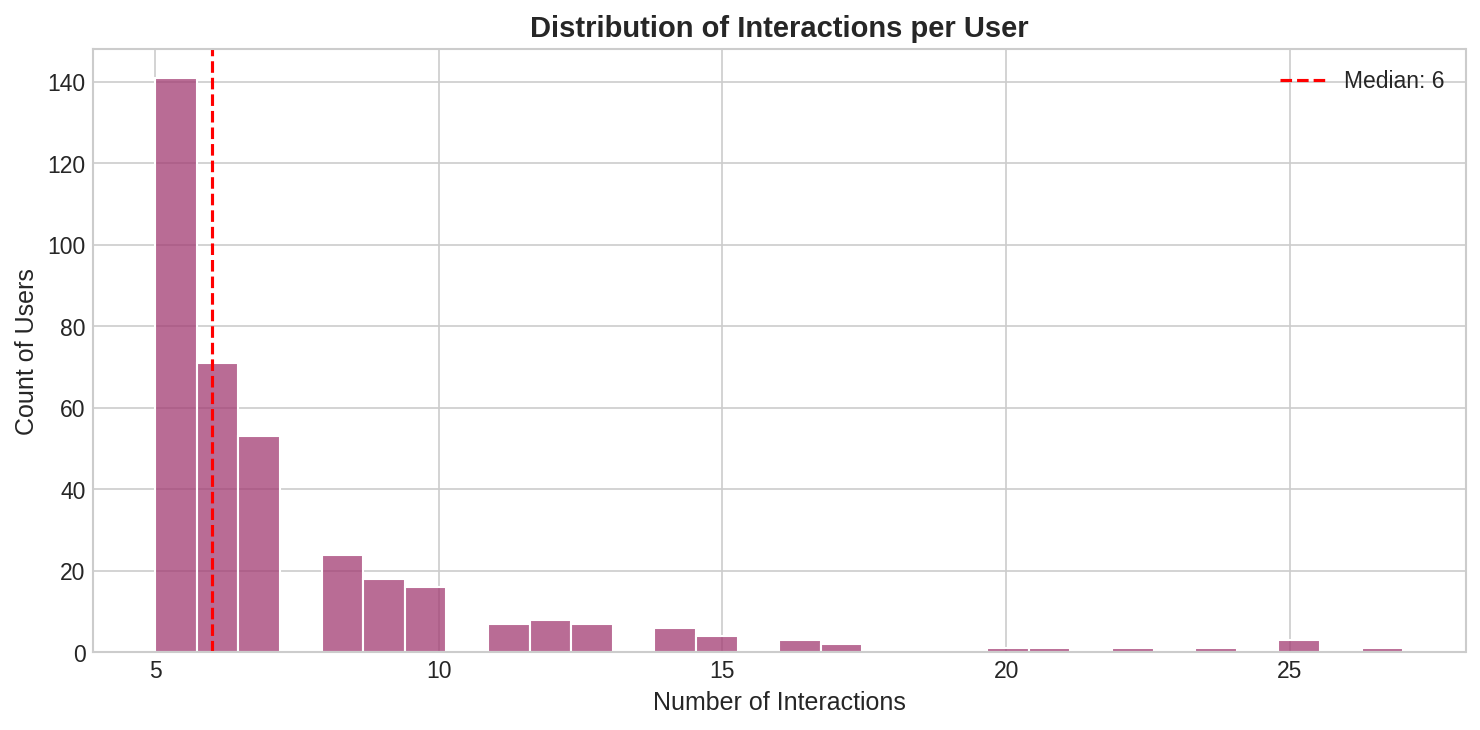

In [21]:
user_counts = df['reviewerID'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(user_counts, bins=30, ax=ax, color='#A23B72', edgecolor='white')
ax.set_title('Distribution of Interactions per User', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Interactions', fontsize=12)
ax.set_ylabel('Count of Users', fontsize=12)
ax.axvline(user_counts.median(), color='red', linestyle='--', label=f'Median: {user_counts.median():.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_user_activity.png', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_user_activity.pdf', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_user_activity.png")
plt.show()


In [22]:
print("\nUser Activity Summary:")
print(f"  Min interactions per user: {user_counts.min()}")
print(f"  Max interactions per user: {user_counts.max()}")
print(f"  Mean interactions per user: {user_counts.mean():.2f}")
print(f"  Median interactions per user: {user_counts.median()}")



User Activity Summary:
  Min interactions per user: 5
  Max interactions per user: 27
  Mean interactions per user: 7.32
  Median interactions per user: 6.0


 ## 4. Item Popularity Distribution

Saved: reports/figures/fig_item_popularity.png


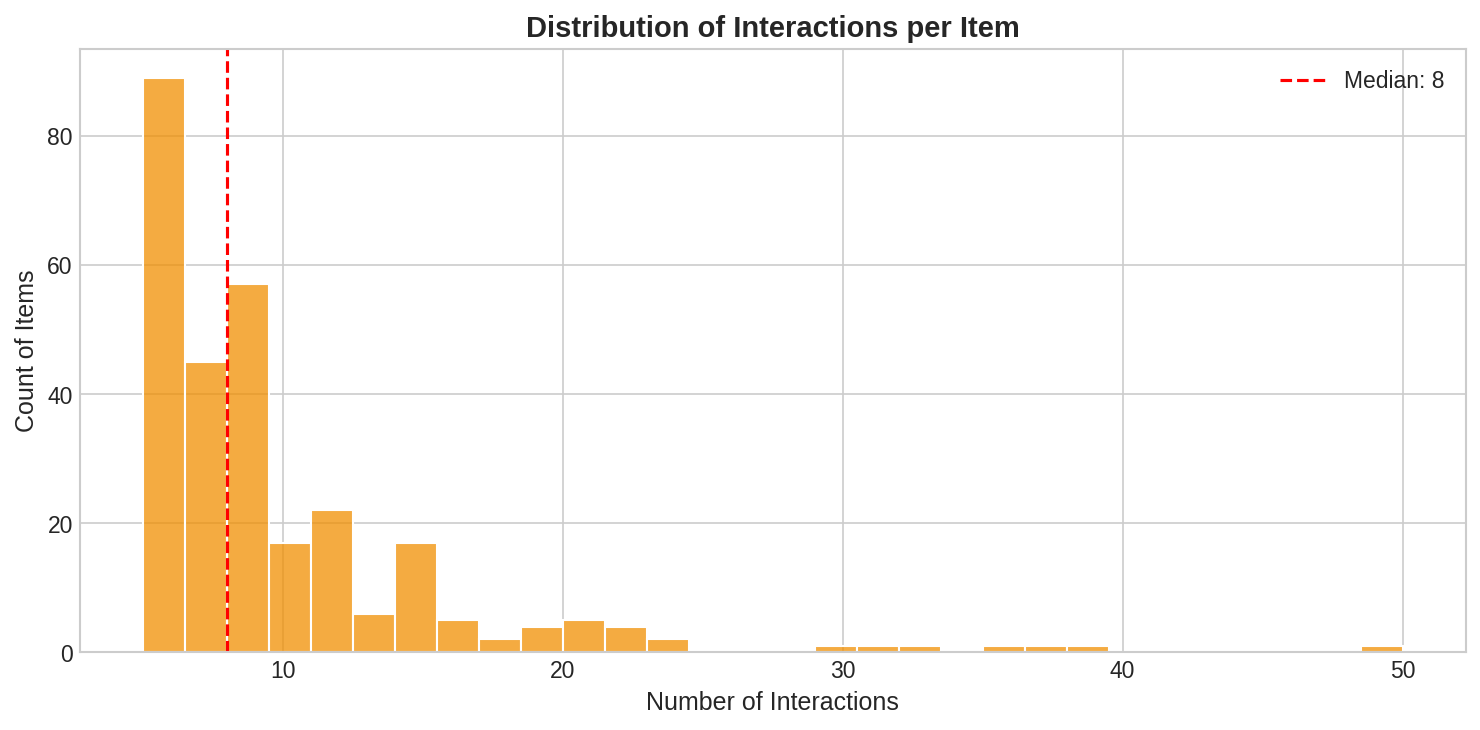

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(item_counts, bins=30, ax=ax, color='#F18F01', edgecolor='white')
ax.set_title('Distribution of Interactions per Item', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Interactions', fontsize=12)
ax.set_ylabel('Count of Items', fontsize=12)
ax.axvline(item_counts.median(), color='red', linestyle='--', label=f'Median: {item_counts.median():.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_item_popularity.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_item_popularity.png")
plt.show()


 ## 5. Temporal Distribution

Saved: reports/figures/fig_temporal.png


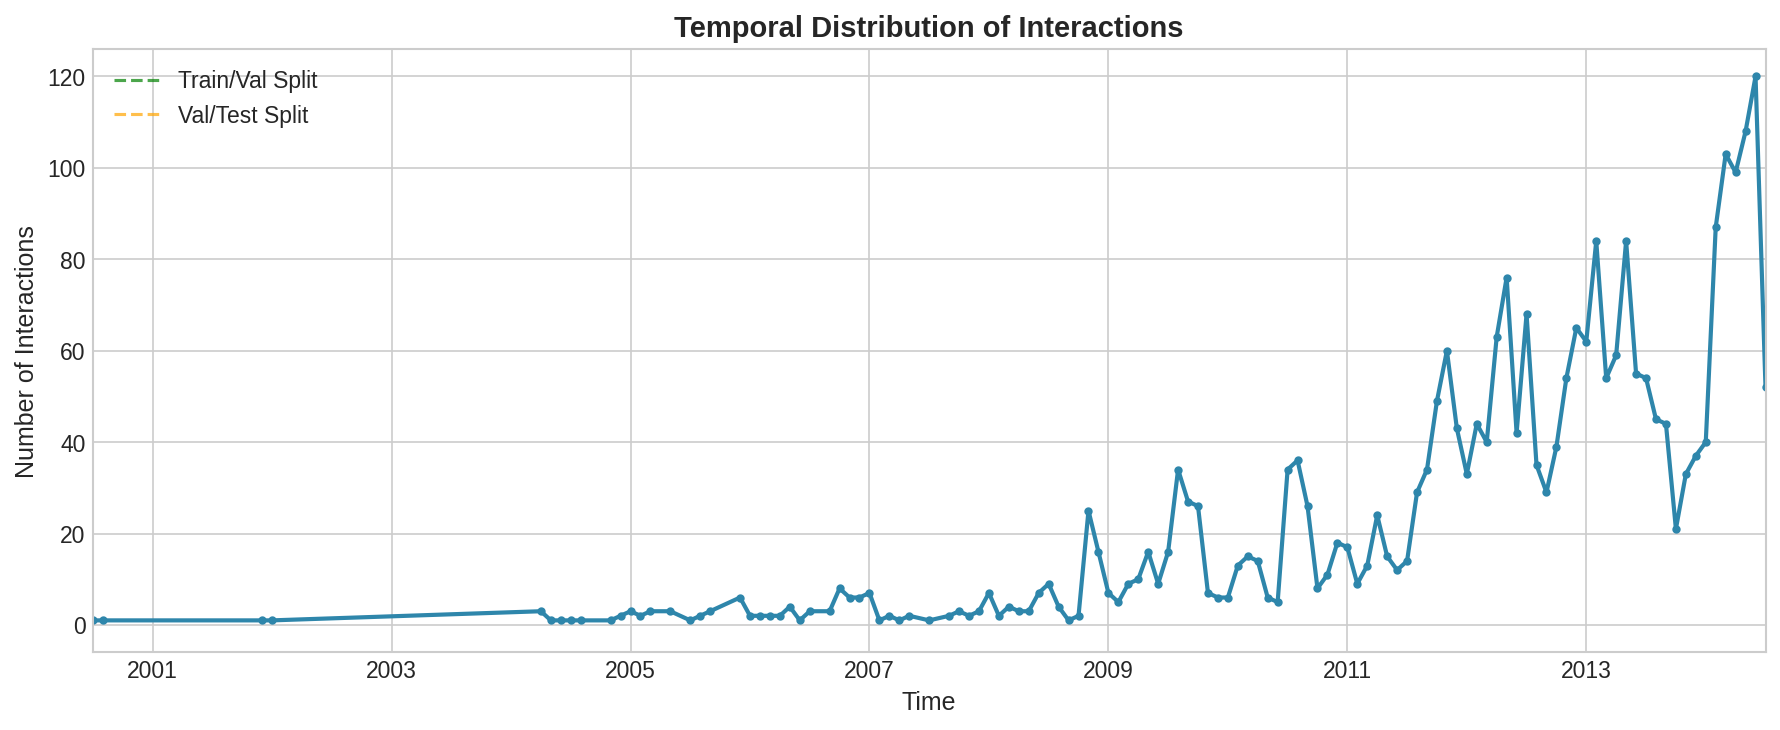

In [24]:
from datetime import datetime

df['date'] = pd.to_datetime(df['unixReviewTime'], unit='s')
df['year_month'] = df['date'].dt.to_period('M')

temporal = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(12, 5))
temporal.plot(kind='line', ax=ax, color='#2E86AB', linewidth=2, marker='o', markersize=3)
ax.set_title('Temporal Distribution of Interactions', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Number of Interactions', fontsize=12)
ax.fill_between(range(len(temporal)), temporal.values, alpha=0.3, color='#2E86AB')

# Mark train/val/test splits
train_end = train['unixReviewTime'].max()
val_end = val['unixReviewTime'].max()
ax.axvline(x=len(temporal)*0.7, color='green', linestyle='--', alpha=0.7, label='Train/Val Split')
ax.axvline(x=len(temporal)*0.85, color='orange', linestyle='--', alpha=0.7, label='Val/Test Split')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_temporal.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_temporal.png")
plt.show()


 ## Summary



 **Key Findings:**

 1. The dataset exhibits extreme sparsity (97.4%), motivating the use of latent factor models.

 2. The long-tail distribution confirms that a few items dominate interactions.

 3. User activity is relatively uniform due to 5-core filtering.

 4. Temporal patterns show consistent activity across the dataset period.